DATASET: https://www.kaggle.com/datasets/nanditapore/credit-risk-analysis


Column Descriptions:

**ID**: Unique identifier for each loan applicant.       
**Age**: Age of the loan applicant.              
**Income**: Income of the loan applicant.       
**Home**: Home ownership status (Own, Mortgage, Rent).    
**Emp_Length**: Employment length in years.    
**Intent**: Purpose of the loan (e.g., education, home improvement).    
**Amount**: Loan amount applied for.    
**Rate**: Interest rate on the loan.    
**Status**: Loan approval status (Fully Paid, Charged Off, Current).    
**Percent_Income**: Loan amount as a percentage of income.    
**Default**: Whether the applicant has defaulted on a loan previously (Yes, No).    
**Cred_Length**: Length of the applicant's credit history.

**Problem Statement:** Can we predict whether a loan applicant will default using their demographic, financial, and loan characteristics — and which of these factors are the strongest predictors of risk?

# **STEP ONE**: Set Up & Load Data

In [67]:
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error as MSE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, roc_curve, auc, precision_score, roc_auc_score
from sklearn.metrics import precision_recall_curve
import xgboost as xgb
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
# Set the API Token variable directly in environment
os.environ["KAGGLE_API_TOKEN"] = "KGAT_16036be840537a3904c9c4d7de9eb8ff"
path = kagglehub.dataset_download("nanditapore/credit-risk-analysis")

Using Colab cache for faster access to the 'credit-risk-analysis' dataset.


In [68]:
# Loading the file
csv_path = os.path.join(path, "credit_risk.csv")
df = pd.read_csv(csv_path)

In [69]:
# Descriptions of bottom 5 and top 5 rows
df

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,32576,57,53000,MORTGAGE,1.0,PERSONAL,5800,13.16,0,0.11,N,30
32577,32577,54,120000,MORTGAGE,4.0,PERSONAL,17625,7.49,0,0.15,N,19
32578,32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,35000,10.99,1,0.46,N,28
32579,32579,56,150000,MORTGAGE,5.0,PERSONAL,15000,11.48,0,0.10,N,26


In [70]:
# All columns printed
df.columns

Index(['Id', 'Age', 'Income', 'Home', 'Emp_length', 'Intent', 'Amount', 'Rate',
       'Status', 'Percent_income', 'Default', 'Cred_length'],
      dtype='object')

In [71]:
# Renaming columns for more specific/understandable names
df.rename(columns={
    "Emp_length": "Employment_In_Years",
    "Cred_length": "Credit_History_Length",
    "Home": "Home_Ownership_Status",
    "Intent": "Loan_Purpose",
    "Amount": "Loan_Amount_Applied",
    "Rate": "Interest_Rate",
    "Default": "Previous_Loan_Default"
}, inplace=True)

In [72]:
# Getting the information for all variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     32581 non-null  int64  
 1   Age                    32581 non-null  int64  
 2   Income                 32581 non-null  int64  
 3   Home_Ownership_Status  32581 non-null  object 
 4   Employment_In_Years    31686 non-null  float64
 5   Loan_Purpose           32581 non-null  object 
 6   Loan_Amount_Applied    32581 non-null  int64  
 7   Interest_Rate          29465 non-null  float64
 8   Status                 32581 non-null  int64  
 9   Percent_income         32581 non-null  float64
 10  Previous_Loan_Default  32581 non-null  object 
 11  Credit_History_Length  32581 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 3.0+ MB


In [73]:
# ID is irrelevant for analyzing or making conclusions from here, therefore it is dropped.
df.drop(columns=['Id'], inplace=True, errors='ignore')

In [74]:
# Getting the count of duplicated variables
df.duplicated().sum()

np.int64(165)

In [75]:
# Knowing how many null values there are and where, and what percent they make up.
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing %
Employment_In_Years,895,2.75
Interest_Rate,3116,9.56


In [76]:
# Know what percentage of people got no (or 0) to status and yes (or 1).
df['Status'].value_counts(normalize=True).round(3)

,proportion
Status,
0,0.782
1,0.218


In [77]:
# Know how many rows and columns we are working with
df.shape

(32581, 11)

## Initial Observations

- The dataset has 32,581 rows and 11 columns (Originally 12, but 'ID' was dropped).
- `Rate` (interest rate) has 9.6% missing values, `Emp_length` has 2.75% missing.
- The target variable `Status` is imbalanced: 78% no-default vs 22% default.
  This means accuracy alone won't be a reliable evaluation metric later.
- Note: `Default` is a separate column indicating *prior* default history —
  not the target. This will be used as a feature, not the label.
                                              
                              UPDATE: The original Step 1 check:
(`df.duplicated().sum()`) showed 0 duplicates, but this was misleading —
it included the `Id` column, which is unique per row by definition and
therefore masks any duplicate feature rows. Re-checking with `Id` excluded
reveals 165 duplicate rows in the raw data. These were identified and
removed during Step 4 (157 remained after outlier removal in Step 2 had
already dropped a few of the duplicate pairs).
- Next step: check for outliers and data quality issues before cleaning.

# **STEP TWO**: Data Cleaning

In [78]:
# Seeing possible unrealistic values for age
df[df['Age'] > 100][['Age', 'Employment_In_Years', 'Income', 'Status']]

,Age,Employment_In_Years,Income,Status
81,144,4.0,250000,0
183,144,4.0,200000,0
575,123,2.0,80004,0
747,123,7.0,78000,0
32297,144,12.0,6000000,0


In [79]:
# Seeing possible unrealistic values for employment in years.
df[df['Employment_In_Years'] > 60][['Age', 'Employment_In_Years', 'Income', 'Status']]

,Age,Employment_In_Years,Income,Status
0,22,123.0,59000,1
210,21,123.0,192000,0


In [80]:
# Remove implausible ages (>100) and implausible employment lengths (>60 years)
before = df.shape[0]
df = df[(df['Age'] <= 100) & (df['Employment_In_Years'] <= 60)]
after = df.shape[0]
print(f"Removed {before - after} rows ({(before-after)/before*100:.2f}% of data)")

Removed 902 rows (2.77% of data)


* We removed rows that had an age greater than 100 or more than 60 years of employment since that's certainly invalid. They also are not a huge part of the data, therefore dropping them should not be an issue since we don't know what the real responses were supposed to be

In [81]:
# Below are all the X variables
numerical_X = [
    'Age',
    'Income',
    'Employment_In_Years',
    'Loan_Amount_Applied',
    'Interest_Rate',
    'Percent_income',
    'Credit_History_Length'
]

# Create a copy of the numerical X data
X_numeric = df[numerical_X].copy()

# Scale the numerical variables
scaler = StandardScaler()

X_numeric_scaled = scaler.fit_transform(X_numeric)

# KNN imputation
imputer = KNNImputer(n_neighbors=5)

X_numeric_imputed_scaled = imputer.fit_transform(X_numeric_scaled)

# Convert back to DataFrame
X_numeric_imputed_scaled = pd.DataFrame(
    X_numeric_imputed_scaled,
    columns=numerical_X,
    index=df.index
)

# Convert values back to the original scale
X_numeric_imputed = pd.DataFrame(
    scaler.inverse_transform(X_numeric_imputed_scaled),
    columns=numerical_X,
    index=df.index
)

df[numerical_X] = X_numeric_imputed

/tmp/ipykernel_391/4007612025.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numerical_X] = X_numeric_imputed


Using KNN Imputation above, we were able to perform imputation where there were missing values such as in Age, Employment_In_Years and Interest_Rate by estimating the missing numerical values in Age, Employment_In_Years and Interest_Rate using similar values nearby, with the help of imputation the final dataset contained no missing values or duplicate observations

In [82]:
# Show total null values for employment in years and interest rate as well as describe both variables
df[['Interest_Rate', 'Employment_In_Years']].isnull().sum()
df[['Interest_Rate', 'Employment_In_Years']].describe()

,Interest_Rate,Employment_In_Years
count,31679.000000,31679.000000
mean,11.037431,4.782064
std,3.109820,4.034948
min,5.420000,0.000000
25%,8.490000,2.000000
50%,10.990000,4.000000
75%,13.220000,7.000000
max,23.220000,41.000000


In [83]:
# Get the data types of all variables
df.dtypes

,0
Age,float64
Income,float64
Home_Ownership_Status,object
Employment_In_Years,float64
Loan_Purpose,object
Loan_Amount_Applied,float64
Interest_Rate,float64
Status,int64
Percent_income,float64
Previous_Loan_Default,object


In [84]:
# Show how many unique values there are for 'object' variables and the 'Status' variable which is binary
for col in ['Home_Ownership_Status', 'Loan_Purpose', 'Previous_Loan_Default', 'Status']:
    print(f"{col}: {df[col].unique()}")

Home_Ownership_Status: ['OWN' 'MORTGAGE' 'RENT' 'OTHER']
Loan_Purpose: ['EDUCATION' 'MEDICAL' 'VENTURE' 'PERSONAL' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
Previous_Loan_Default: ['N' 'Y']
Status: [0 1]


In [85]:
# Object columns that are genuinely categorical -> category dtype
# (saves memory, and signals intent clearly to anyone reading the notebook)
df['Home_Ownership_Status'] = df['Home_Ownership_Status'].astype('category')
df['Loan_Purpose'] = df['Loan_Purpose'].astype('category')

# Previous_Loan_Default is Y/N text - convert to binary (0/1) for modeling later
df['Previous_Loan_Default'] = df['Previous_Loan_Default'].map({'Y': 1, 'N': 0})

# Status is already 0/1 int - just confirm it's treated as the target, no change needed
df['Status'] = df['Status'].astype(int)

# Employment_In_Years and Credit_History_Length are counts - int makes more sense than float
df['Employment_In_Years'] = df['Employment_In_Years'].round().astype(int)
df['Credit_History_Length'] = df['Credit_History_Length'].astype(int)

/tmp/ipykernel_391/3405399827.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Home_Ownership_Status'] = df['Home_Ownership_Status'].astype('category')
/tmp/ipykernel_391/3405399827.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Loan_Purpose'] = df['Loan_Purpose'].astype('category')
/tmp/ipykernel_391/3405399827.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [86]:
# Check that the updated data types are working
df.dtypes

,0
Age,float64
Income,float64
Home_Ownership_Status,category
Employment_In_Years,int64
Loan_Purpose,category
Loan_Amount_Applied,float64
Interest_Rate,float64
Status,int64
Percent_income,float64
Previous_Loan_Default,int64


In [87]:
# These columns had no missing values and are naturally whole numbers,
# but became float64 due to the StandardScaler/KNNImputer round-trip.
# Percent_income is a genuine ratio, so it correctly stays float.
df['Age'] = df['Age'].round().astype(int)
df['Income'] = df['Income'].round().astype(int)
df['Loan_Amount_Applied'] = df['Loan_Amount_Applied'].round().astype(int)

/tmp/ipykernel_391/910793858.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age'] = df['Age'].round().astype(int)
/tmp/ipykernel_391/910793858.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income'] = df['Income'].round().astype(int)
/tmp/ipykernel_391/910793858.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/

In [88]:
# Check that the datatypes have been updated
df.dtypes

,0
Age,int64
Income,int64
Home_Ownership_Status,category
Employment_In_Years,int64
Loan_Purpose,category
Loan_Amount_Applied,int64
Interest_Rate,float64
Status,int64
Percent_income,float64
Previous_Loan_Default,int64


## Data Cleaning Steps Taken

- Removed rows with implausible values: Age > 100, Employment_In_Years > 60
  (data entry errors, not legitimate extremes)
- Imputed missing values in Interest_Rate (9.6%) and Employment_In_Years (2.75%)
  using KNNImputer (k=5) on standardized numeric features, rather than simple
  median imputation, to preserve relationships between correlated variables
- Converted Home_Ownership_Status and Loan_Purpose to category dtype
- Converted Previous_Loan_Default from Y/N text to binary 0/1
- Corrected dtypes for Age, Income, Loan_Amount_Applied, and Employment_In_Years
  back to int64 after the scaling/imputation round-trip introduced float64
- Verified: 0 missing values remain, no duplicate rows

# **STEP THREE**: Exploratory Data Analysis

/tmp/ipykernel_391/717372147.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette=['#4C72B0', '#DD8452'])


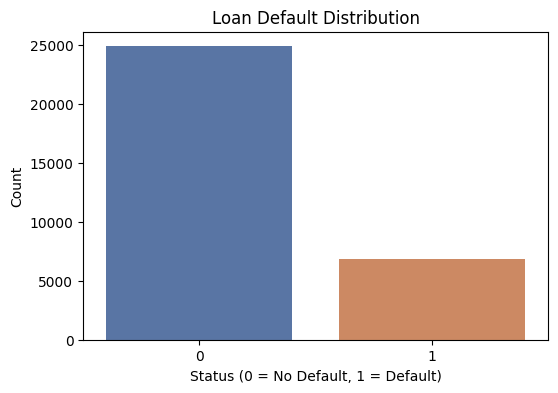

Status
0    0.785
1    0.215
Name: proportion, dtype: float64


In [89]:
# Target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', palette=['#4C72B0', '#DD8452'])
plt.title('Loan Default Distribution')
plt.xlabel('Status (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.show()

# Print the yes/no values for our Y variable 'Status'
print(df['Status'].value_counts(normalize=True).round(3))

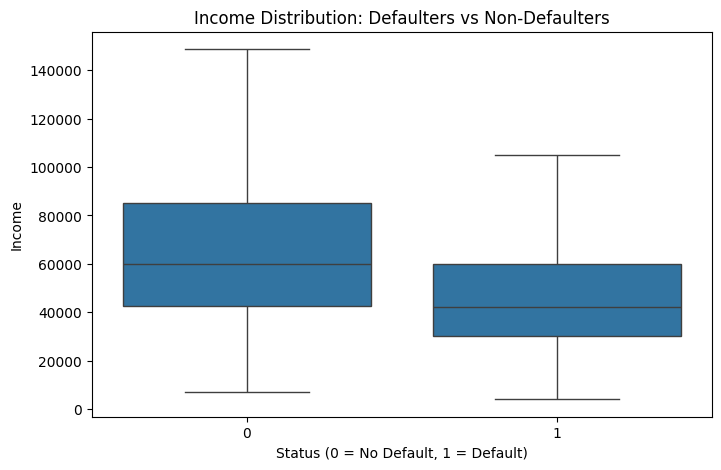

In [90]:
# Income by default status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Status', y='Income', showfliers=False)
plt.title('Income Distribution: Defaulters vs Non-Defaulters')
plt.xlabel('Status (0 = No Default, 1 = Default)')
plt.ylabel('Income')
plt.show()

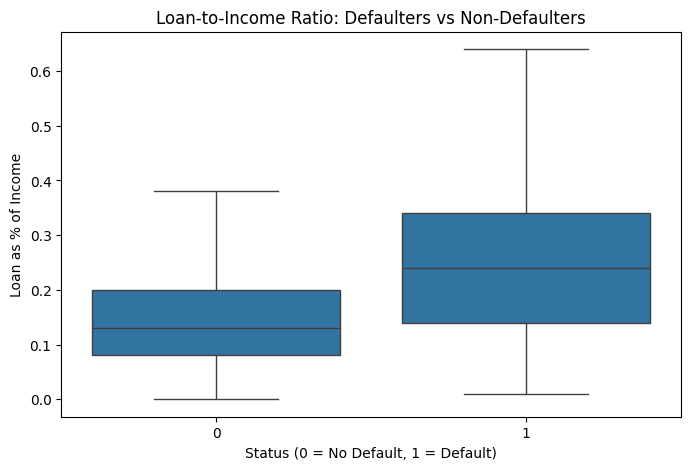

In [91]:
# Loan-to-income ratio by default status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Status', y='Percent_income', showfliers=False)
plt.title('Loan-to-Income Ratio: Defaulters vs Non-Defaulters')
plt.xlabel('Status (0 = No Default, 1 = Default)')
plt.ylabel('Loan as % of Income')
plt.show()

/tmp/ipykernel_391/178268236.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  purpose_default = df.groupby('Loan_Purpose')['Status'].mean().sort_values(ascending=False)
/tmp/ipykernel_391/178268236.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purpose_default.index, y=purpose_default.values, palette='viridis')


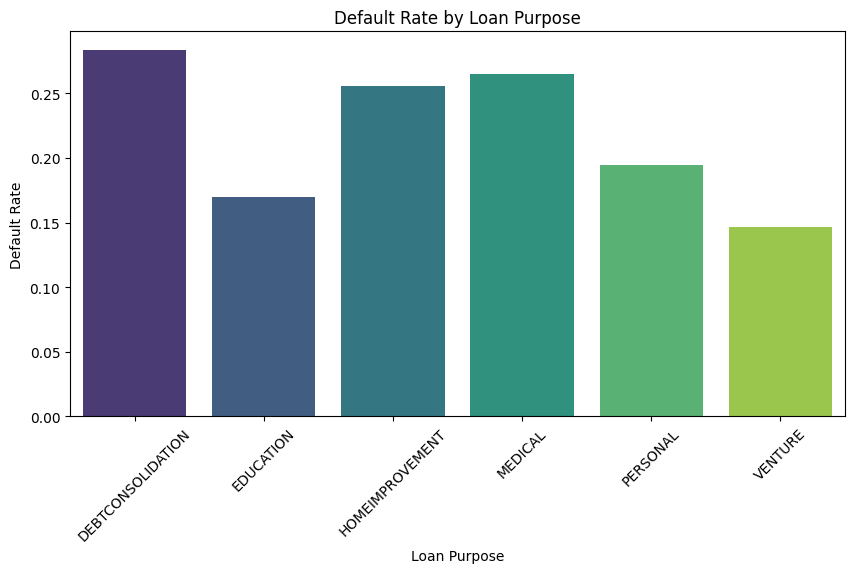

In [92]:
# Default rate by loan purpose
plt.figure(figsize=(10,5))
purpose_default = df.groupby('Loan_Purpose')['Status'].mean().sort_values(ascending=False)
sns.barplot(x=purpose_default.index, y=purpose_default.values, palette='viridis')
plt.title('Default Rate by Loan Purpose')
plt.ylabel('Default Rate')
plt.xlabel('Loan Purpose')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_391/4002013755.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  home_default = df.groupby('Home_Ownership_Status')['Status'].mean().sort_values(ascending=False)
/tmp/ipykernel_391/4002013755.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=home_default.index, y=home_default.values, palette='magma')


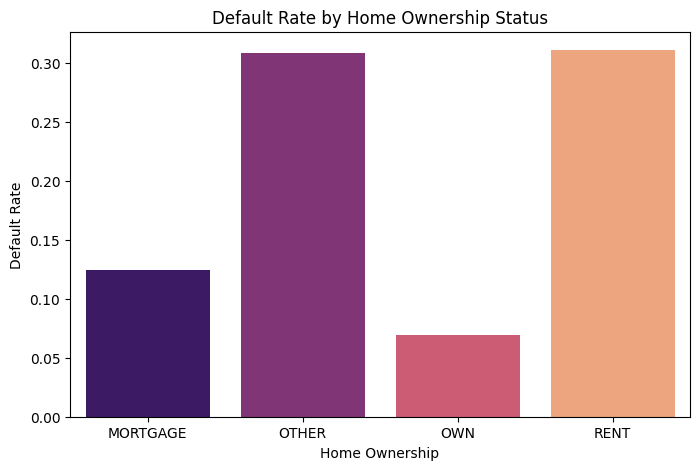

In [93]:
# Default rate by home ownership
plt.figure(figsize=(8,5))
home_default = df.groupby('Home_Ownership_Status')['Status'].mean().sort_values(ascending=False)
sns.barplot(x=home_default.index, y=home_default.values, palette='magma')
plt.title('Default Rate by Home Ownership Status')
plt.ylabel('Default Rate')
plt.xlabel('Home Ownership')
plt.show()

/tmp/ipykernel_391/1598199119.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Correlations:
Percent_income           0.379823
Interest_Rate            0.324579
Previous_Loan_Default    0.181090
Income                  -0.164128
Loan_Amount_Applied      0.112188
Employment_In_Years     -0.085966
Age                     -0.022130
Credit_History_Length   -0.016830
dtype: float64


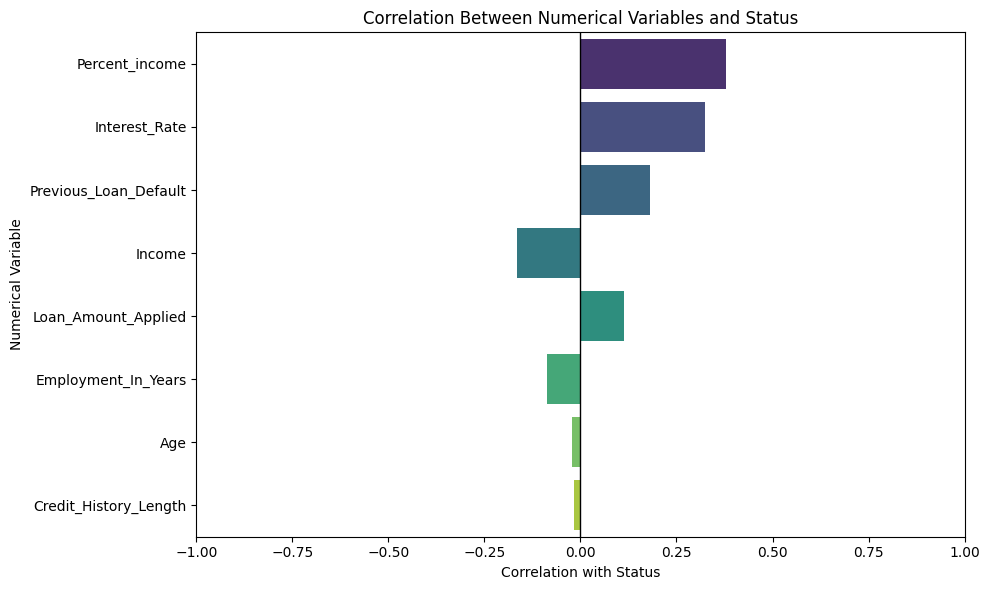

In [94]:
default_numeric = df['Status']

# Get all numerical X variables, excluding ID
numerical_cols = df.drop(columns=['Id', 'Status'], errors='ignore') \
                   .select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation with Default
correlations = df[numerical_cols].corrwith(default_numeric)

# Sort by absolute correlation
correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

# Print correlations to verify data
print("Correlations:")
print(correlations)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    x=correlations.values,
    y=correlations.index,
    palette=sns.color_palette("viridis", n_colors=len(correlations)) # Assign a unique color to each bar
)

plt.axvline(0, color='black', linewidth=1)
plt.xlim(-1, 1) # Set x-axis limits from -1 to 1

plt.title('Correlation Between Numerical Variables and Status')
plt.xlabel('Correlation with Status')
plt.ylabel('Numerical Variable')

plt.tight_layout()
plt.show()

<Axes: xlabel='Status', ylabel='Income'>

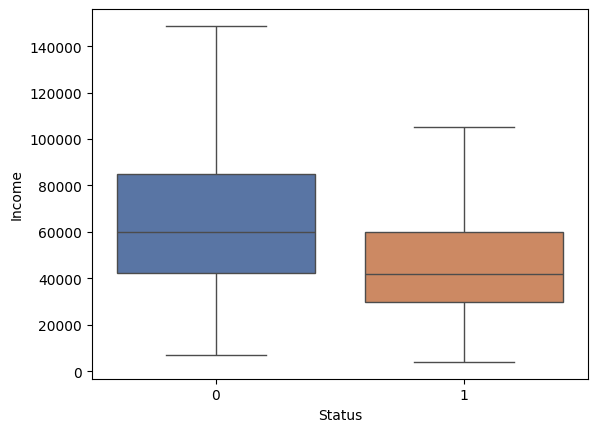

In [95]:
sns.boxplot(data=df, x='Status', y='Income', hue='Status',
            palette=['#4C72B0', '#DD8452'], legend=False, showfliers=False)

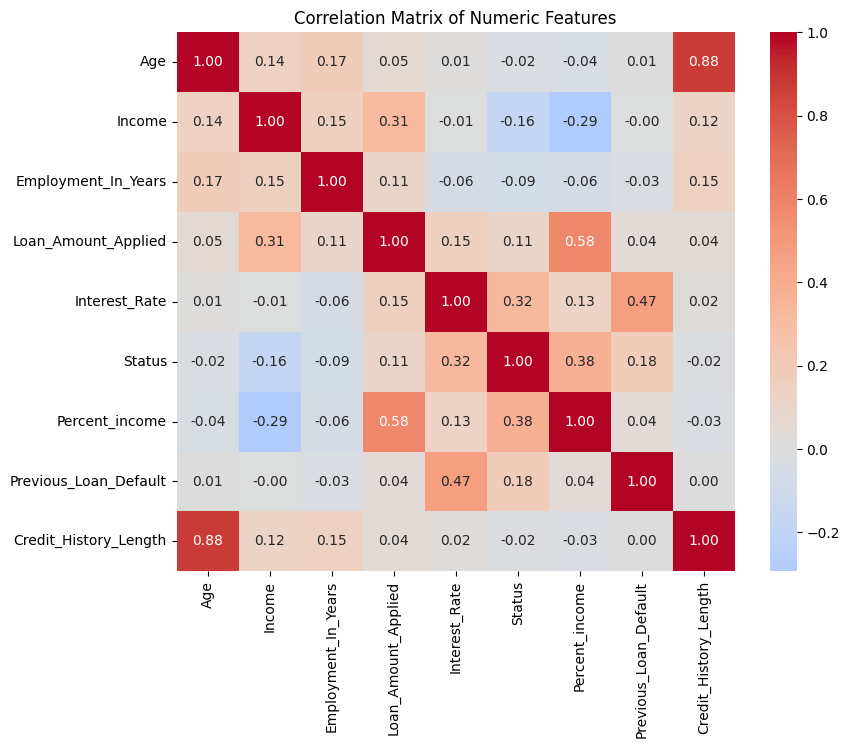

In [96]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Data Visualized and Analyzed

 Loan-to-income ratio shows much clearer separation between
defaulters and non-defaulters than income alone, confirming it as a stronger
predictor. Home ownership status is also highly informative — owners default
at roughly 1/4 the rate of renters. The correlation matrix confirms these
patterns numerically and flags a multicollinearity concern: Age and
Credit_History_Length are correlated at 0.88, which will need consideration
during feature selection, particularly for the logistic regression baseline.

# **STEP FOUR**: Feature Engineering

In [97]:
print("Correlation with Status:")
print(f"Age: {df['Age'].corr(df['Status']):.3f}")
print(f"Credit_History_Length: {df['Credit_History_Length'].corr(df['Status']):.3f}")

Correlation with Status:
Age: -0.022
Credit_History_Length: -0.017


In [98]:
categorical_cols = ['Home_Ownership_Status', 'Loan_Purpose']

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Home_Ownership_Status
Home_Ownership_Status
RENT        16072
MORTGAGE    13090
OWN          2410
OTHER         107
Name: count, dtype: int64

Loan_Purpose
Loan_Purpose
EDUCATION            6288
MEDICAL              5897
VENTURE              5553
PERSONAL             5367
DEBTCONSOLIDATION    5064
HOMEIMPROVEMENT      3510
Name: count, dtype: int64


In [99]:
df.columns.tolist()

['Age',
 'Income',
 'Home_Ownership_Status',
 'Employment_In_Years',
 'Loan_Purpose',
 'Loan_Amount_Applied',
 'Interest_Rate',
 'Status',
 'Percent_income',
 'Previous_Loan_Default',
 'Credit_History_Length']

In [100]:
print(df.dtypes)

Age                         int64
Income                      int64
Home_Ownership_Status    category
Employment_In_Years         int64
Loan_Purpose             category
Loan_Amount_Applied         int64
Interest_Rate             float64
Status                      int64
Percent_income            float64
Previous_Loan_Default       int64
Credit_History_Length       int64
dtype: object


In [101]:
print(df.columns.tolist())

['Age', 'Income', 'Home_Ownership_Status', 'Employment_In_Years', 'Loan_Purpose', 'Loan_Amount_Applied', 'Interest_Rate', 'Status', 'Percent_income', 'Previous_Loan_Default', 'Credit_History_Length']


In [102]:
# FIX
df['loan_to_income'] = (df['Loan_Amount_Applied'] / df['Income'].replace(0, pd.NA)).round(2)

print(df[['Percent_income', 'loan_to_income']].corr())
print("Missing values created:", df['loan_to_income'].isnull().sum())

                Percent_income  loan_to_income
Percent_income        1.000000        0.999179
loan_to_income        0.999179        1.000000
Missing values created: 0


/tmp/ipykernel_391/4035187027.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['loan_to_income'] = (df['Loan_Amount_Applied'] / df['Income'].replace(0, pd.NA)).round(2)


In [103]:
df = df.drop(columns=['loan_to_income'])

In [104]:
print(df[['Loan_Amount_Applied', 'Income']].head())

   Loan_Amount_Applied  Income
1                 1000    9600
2                 5500    9600
3                35000   65500
4                35000   54400
5                 2500    9900


In [105]:
print("df shape:", df.shape)
print("Target (Status) shape:", df['Status'].shape)

print("\nMissing values in df:")
print(df.isnull().sum().sum())

print("\nMissing values in Target (Status):")
print(df['Status'].isnull().sum())

print("\nTarget (Status) column present in df?")
print('Status' in df.columns)

print("\ndf data types:")
print(df.dtypes)

df shape: (31679, 11)
Target (Status) shape: (31679,)

Missing values in df:
0

Missing values in Target (Status):
0

Target (Status) column present in df?
True

df data types:
Age                         int64
Income                      int64
Home_Ownership_Status    category
Employment_In_Years         int64
Loan_Purpose             category
Loan_Amount_Applied         int64
Interest_Rate             float64
Status                      int64
Percent_income            float64
Previous_Loan_Default       int64
Credit_History_Length       int64
dtype: object


In [106]:
df = df.drop_duplicates()
df_encoded = pd.get_dummies(df, columns=['Home_Ownership_Status', 'Loan_Purpose'],
                          drop_first=True)

X = df_encoded.drop(columns=['Status'])
y = df_encoded['Status']

assert X.isnull().sum().sum() == 0, "Missing values still present!"
assert 'Status' not in X.columns, "Target leaked into features!"
assert X.shape[0] == 31522, f"Expected 31522 rows, got {X.shape[0]} — duplicates or outliers not applied!"
assert not any(X.dtypes == 'category'), "Categorical columns not encoded!"

print("✅ X is clean and ready for train/test split.")
print("Final shape:", X.shape)
print("Final columns:", X.columns.tolist())

✅ X is clean and ready for train/test split.
Final shape: (31522, 16)
Final columns: ['Age', 'Income', 'Employment_In_Years', 'Loan_Amount_Applied', 'Interest_Rate', 'Percent_income', 'Previous_Loan_Default', 'Credit_History_Length', 'Home_Ownership_Status_OTHER', 'Home_Ownership_Status_OWN', 'Home_Ownership_Status_RENT', 'Loan_Purpose_EDUCATION', 'Loan_Purpose_HOMEIMPROVEMENT', 'Loan_Purpose_MEDICAL', 'Loan_Purpose_PERSONAL', 'Loan_Purpose_VENTURE']


In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (25217, 16)
Test shape: (6305, 16)

Train target distribution:
Status
0    0.784
1    0.216
Name: proportion, dtype: float64

Test target distribution:
Status
0    0.784
1    0.216
Name: proportion, dtype: float64


In [108]:
print("Final X shape:", X.shape)
print("Final X columns:", X.columns.tolist())
print("Missing values in final X:", X.isnull().sum().sum())
print("Target leaked into X?", 'Status' in X.columns)

Final X shape: (31522, 16)
Final X columns: ['Age', 'Income', 'Employment_In_Years', 'Loan_Amount_Applied', 'Interest_Rate', 'Percent_income', 'Previous_Loan_Default', 'Credit_History_Length', 'Home_Ownership_Status_OTHER', 'Home_Ownership_Status_OWN', 'Home_Ownership_Status_RENT', 'Loan_Purpose_EDUCATION', 'Loan_Purpose_HOMEIMPROVEMENT', 'Loan_Purpose_MEDICAL', 'Loan_Purpose_PERSONAL', 'Loan_Purpose_VENTURE']
Missing values in final X: 0
Target leaked into X? False


In [109]:
print("Current df shape:", df.shape)
print("Missing values in df:", df.isnull().sum().sum())
print("Duplicate rows in df:", df.duplicated().sum())

Current df shape: (31522, 11)
Missing values in df: 0
Duplicate rows in df: 0


In [110]:
# See what the duplicates actually look like
dupes = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print(dupes.head(20))
print("\nTotal duplicate rows (including first occurrence):", dupes.shape[0])

Empty DataFrame
Columns: [Age, Income, Home_Ownership_Status, Employment_In_Years, Loan_Purpose, Loan_Amount_Applied, Interest_Rate, Status, Percent_income, Previous_Loan_Default, Credit_History_Length]
Index: []

Total duplicate rows (including first occurrence): 0


In [111]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Dropped {before - after} duplicate rows. New shape: {df.shape}")

Dropped 0 duplicate rows. New shape: (31522, 11)


In [112]:
# Run this right now, without changing anything else
print("Current df shape:", df.shape)
print("Current df duplicate count:", df.duplicated().sum())

Current df shape: (31522, 11)
Current df duplicate count: 0


## Feature Engineering
- One-hot encoded Home_Ownership_Status and Loan_Purpose (drop_first=True
  to avoid the dummy variable trap)
- Investigated and dropped `loan_to_income` (correlation 0.999 with existing
  Percent_income — redundant feature)
- Found and removed 165 duplicate rows present in the original source data
  (157 remained after Step 2's outlier removal had already dropped a few
  duplicate pairs) — correcting an earlier Step 1 check that missed this
  because it included the unique Id column
- Final dataset: 31,522 rows, 16 features after encoding
- Train/test split: 80/20, stratified on Status (78.5%/21.5% preserved in
  both sets)

# **STEP FIVE**: Build And Compare Models

In [113]:
# Initialize StandardScaler for feature scaling. This is crucial for distance-based models like Logistic Regression.
scaler = StandardScaler()
# Fit the scaler on the training data and transform it. Transform the test data using the *same* fitted scaler.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train a Logistic Regression model.
# max_iter is set to 1000 to ensure convergence.
# random_state is for reproducibility.
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data.
log_reg_pred = log_reg.predict(X_test_scaled)
# Get prediction probabilities for the positive class (Status=1) for ROC-AUC calculation.
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [114]:
# Initialize and train a Decision Tree Classifier.
# max_depth limits the tree's depth to prevent overfitting.
# random_state is for reproducibility.
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)  # Tree-based models generally do not require feature scaling.

# Make predictions on the unscaled test data.
dt_pred = dt.predict(X_test)
# Get prediction probabilities for the positive class (Status=1).
dt_proba = dt.predict_proba(X_test)[:, 1]

In [115]:
# Initialize and train a Random Forest Classifier.
# n_estimators sets the number of trees in the forest.
# max_depth limits the depth of each tree.
# n_jobs=-1 uses all available processors for faster training.
# random_state is for reproducibility.
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Make predictions on the test data.
rf_pred = rf.predict(X_test)
# Get prediction probabilities for the positive class (Status=1).
rf_proba = rf.predict_proba(X_test)[:, 1]

In [116]:
# Initialize and train an XGBoost Classifier.
# n_estimators is the number of boosting rounds.
# max_depth limits the depth of each tree.
# learning_rate shrinks the step size at each boosting iteration.
# eval_metric='logloss' specifies the evaluation metric to optimize.
# random_state is for reproducibility.
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Make predictions on the test data.
xgb_pred = xgb_model.predict(X_test)
# Get prediction probabilities for the positive class (Status=1).
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

In [117]:
# Initialize and train a LightGBM Classifier.
# n_estimators is the number of boosting rounds.
# max_depth limits the depth of each tree.
# learning_rate shrinks the step size at each boosting iteration.
# verbose=-1 suppresses output during training.
# random_state is for reproducibility.
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)

# Make predictions on the test data.
lgbm_pred = lgbm_model.predict(X_test)
# Get prediction probabilities for the positive class (Status=1).
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]

## Models built and compared

Five classification models were trained, ranging from simple/interpretable
to complex/high-performing:

- **Logistic Regression** — linear baseline, trained on scaled features
  (required, since it's distance/gradient-based)
- **Decision Tree** (max_depth=6) — single tree, depth-limited to reduce
  overfitting
- **Random Forest** (200 trees, max_depth=10) — ensemble of trees, reduces
  variance compared to a single Decision Tree
- **XGBoost** (200 estimators, max_depth=6, lr=0.1) — gradient boosting,
  often a strong performer on tabular data
- **LightGBM** (200 estimators, max_depth=6, lr=0.1) — gradient boosting
  with faster training via leaf-wise tree growth

**Key design choice:** Logistic Regression used `X_train_scaled`/`X_test_scaled`
(fit only on train, to avoid data leakage), while all tree-based models used
the original unscaled `X_train`/`X_test`, since tree splits are based on
thresholds rather than distances and don't benefit from scaling.

**Note:** Hyperparameters used here (`max_depth`, `n_estimators`, `learning_rate`)
are reasonable defaults, not yet tuned. This is intentional — the goal at this
stage is a fair baseline comparison across model types before investing time
tuning whichever model shows the most promise.

# **STEP SIX**: Evaluate The Right Metrics

In [118]:
# Store the true labels, predicted classes, and predicted probabilities for each model.
# This dictionary allows for easy iteration and evaluation of all models.
results = {
    'Logistic Regression': (y_test, log_reg_pred, log_reg_proba),
    'Decision Tree': (y_test, dt_pred, dt_proba),
    'Random Forest': (y_test, rf_pred, rf_proba),
    'XGBoost': (y_test, xgb_pred, xgb_proba),
    'LightGBM': (y_test, lgbm_pred, lgbm_proba)
}

# Initialize an empty list to store performance metrics for each model.
comparison = []
# Iterate through each model's results to calculate and store metrics.
for name, (y_true, y_pred, y_proba) in results.items():
    comparison.append({
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    })

# Convert the list of dictionaries into a Pandas DataFrame for better readability and sorting.
comparison_df = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
# Display the comparison table, rounding metrics to 3 decimal places.
comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
4,LightGBM,0.928,0.947,0.706,0.809,0.943
3,XGBoost,0.928,0.948,0.707,0.810,0.942
2,Random Forest,0.918,0.957,0.648,0.772,0.921
1,Decision Tree,0.911,0.972,0.606,0.746,0.887
0,Logistic Regression,0.848,0.738,0.463,0.569,0.859


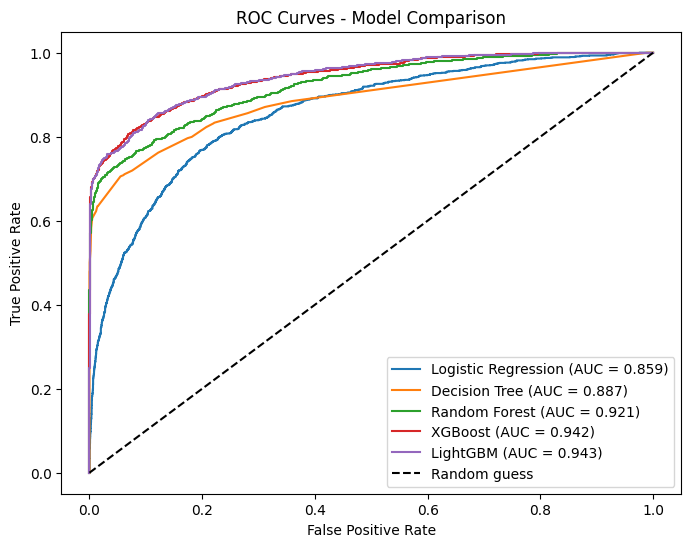

In [119]:
# Create a new figure for the ROC curve plot.
plt.figure(figsize=(8, 6))
# Iterate through each model to plot its ROC curve.
for name, (y_true, y_pred, y_proba) in results.items():
    # Calculate False Positive Rate (fpr), True Positive Rate (tpr), and thresholds for the ROC curve.
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    # Calculate the Area Under the Receiver Operating Characteristic Curve (ROC-AUC).
    auc_score = roc_auc_score(y_true, y_proba)
    # Plot the ROC curve for the current model, including its AUC score in the label.
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Plot the diagonal dashed line representing a random guess classifier.
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
# Label the x-axis as 'False Positive Rate'.
plt.xlabel('False Positive Rate')
# Label the y-axis as 'True Positive Rate'.
plt.ylabel('True Positive Rate')
# Set the title of the plot.
plt.title('ROC Curves - Model Comparison')
# Display the legend to identify each model's curve.
plt.legend()
# Show the plot.
plt.show()

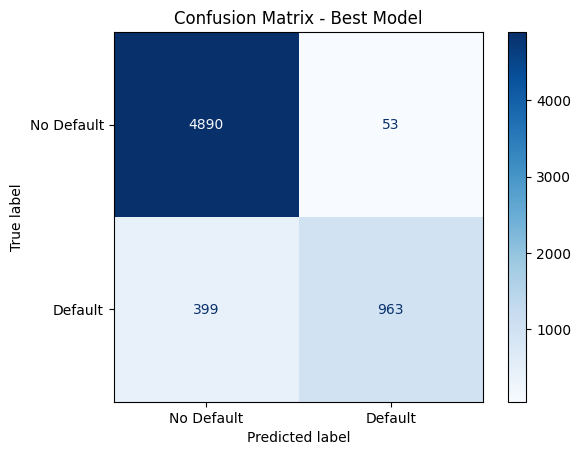

In [120]:
# Select the best performing model's predictions based on the comparison_df. Here, XGBoost was selected.
best_pred = xgb_pred  # update this based on comparison_df results
# Compute the confusion matrix using the true labels and the best model's predictions.
cm = confusion_matrix(y_test, best_pred)

# Create a ConfusionMatrixDisplay object for visualization.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
# Plot the confusion matrix with a 'Blues' colormap.
disp.plot(cmap='Blues')
# Set the title of the confusion matrix plot.
plt.title('Confusion Matrix - Best Model')
# Show the plot.
plt.show()

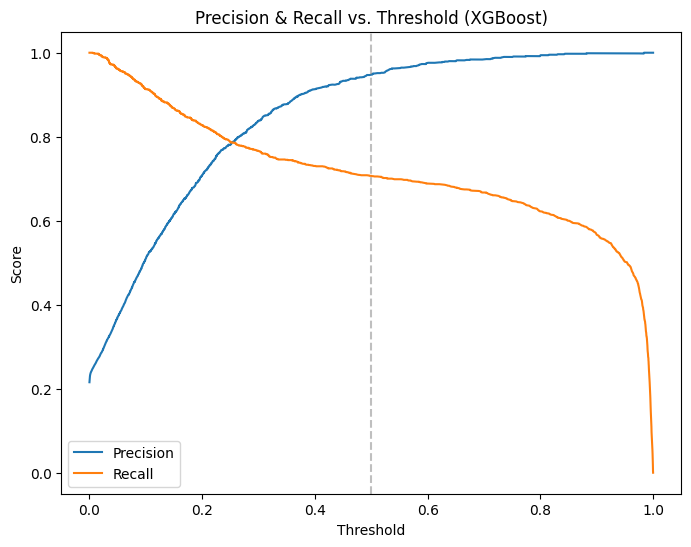

In [121]:
# Calculate precision-recall pairs for various probability thresholds for XGBoost.
# (Can be swapped for lgbm_proba if LightGBM is preferred).
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_proba)

# Create a new figure for the Precision-Recall vs. Threshold plot.
plt.figure(figsize=(8, 6))
# Plot precision against thresholds.
plt.plot(thresholds, precisions[:-1], label='Precision')
# Plot recall against thresholds.
plt.plot(thresholds, recalls[:-1], label='Recall')
# Label the x-axis as 'Threshold'.
plt.xlabel('Threshold')
# Label the y-axis as 'Score'.
plt.ylabel('Score')
# Set the title of the plot.
plt.title('Precision & Recall vs. Threshold (XGBoost)')
# Display the legend.
plt.legend()
# Add a vertical line at the default threshold of 0.5 for reference.
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold')
# Show the plot.
plt.show()

In [122]:
# Define a function to evaluate model metrics at a given classification threshold.
def evaluate_at_threshold(y_true, y_proba, threshold):
    # Convert probabilities to binary predictions based on the specified threshold.
    y_pred_thresh = (y_proba >= threshold).astype(int)
    # Return a dictionary containing Precision, Recall, F1-score, and Accuracy at this threshold.
    return {
        'Threshold': threshold,
        'Precision': precision_score(y_true, y_pred_thresh),
        'Recall': recall_score(y_true, y_pred_thresh),
        'F1': f1_score(y_true, y_pred_thresh),
        'Accuracy': accuracy_score(y_true, y_pred_thresh)
    }

# Calculate evaluation metrics for XGBoost at a set of predefined thresholds (0.5, 0.4, 0.3, 0.2, 0.15).
threshold_results = [evaluate_at_threshold(y_test, xgb_proba, t)
                      for t in [0.5, 0.4, 0.3, 0.2, 0.15]]

# Display the results in a DataFrame, rounded to 3 decimal places.
pd.DataFrame(threshold_results).round(3)

,Threshold,Precision,Recall,F1,Accuracy
0,0.50,0.948,0.707,0.810,0.928
1,0.40,0.914,0.731,0.812,0.927
2,0.30,0.838,0.766,0.800,0.917
3,0.20,0.709,0.827,0.764,0.889
4,0.15,0.616,0.867,0.721,0.855


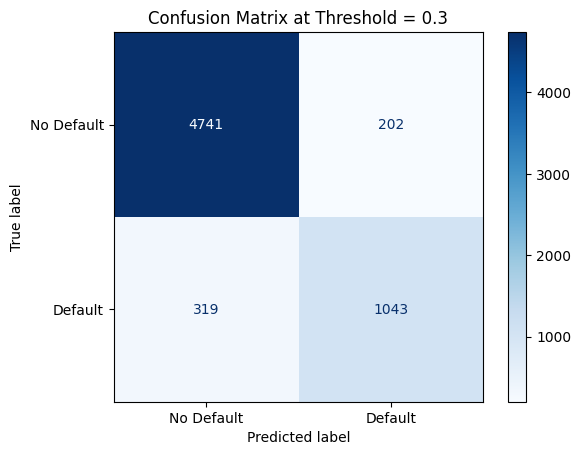

At threshold 0.3:
Recall: 0.766 (was 0.707 at default 0.5)
Precision: 0.838 (was 0.948 at default 0.5)


In [123]:
# Set the chosen classification threshold for further analysis.
chosen_threshold = 0.3
# Generate binary predictions using the chosen threshold on XGBoost probabilities.
y_pred_adjusted = (xgb_proba >= chosen_threshold).astype(int)

# Compute the confusion matrix with the adjusted predictions.
cm_adjusted = confusion_matrix(y_test, y_pred_adjusted)
# Create a ConfusionMatrixDisplay object for the adjusted confusion matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm_adjusted, display_labels=['No Default', 'Default'])
# Plot the adjusted confusion matrix.
disp.plot(cmap='Blues')
# Set the title of the plot to include the chosen threshold.
plt.title(f'Confusion Matrix at Threshold = {chosen_threshold}')
# Show the plot.
plt.show()

# Print the Recall and Precision scores at the chosen threshold and compare with the default 0.5 threshold.
print(f"At threshold {chosen_threshold}:")
print(f"Recall: {recall_score(y_test, y_pred_adjusted):.3f} (was {recall_score(y_test, xgb_pred):.3f} at default 0.5)")
print(f"Precision: {precision_score(y_test, y_pred_adjusted):.3f} (was {precision_score(y_test, xgb_pred):.3f} at default 0.5)")

In [124]:
# Define a function to calculate the business cost based on false negatives and false positives.
# cost_fn: cost of a false negative (missing an actual defaulter).
# cost_fp: cost of a false positive (incorrectly classifying a non-defaulter as a defaulter).
def business_cost(y_true, y_proba, threshold, cost_fn=5, cost_fp=1):
    # Convert probabilities to binary predictions using the given threshold.
    y_pred = (y_proba >= threshold).astype(int)
    # Compute the confusion matrix.
    cm = confusion_matrix(y_true, y_pred)
    # Extract True Negatives, False Positives, False Negatives, and True Positives.
    tn, fp, fn, tp = cm.ravel()
    # Calculate the total business cost.
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    return total_cost

# Initialize an empty list to store cost results for various thresholds.
cost_results = []
# Iterate through a set of predefined thresholds.
for t in [0.5, 0.4, 0.3, 0.2, 0.15]:
    # Calculate the business cost for each threshold.
    cost = business_cost(y_test, xgb_proba, t)
    # Append the threshold and its estimated cost to the results list.
    cost_results.append({'Threshold': t, 'Estimated Cost': cost})

# Convert the list of dictionaries to a DataFrame and display it.
pd.DataFrame(cost_results)

,Threshold,Estimated Cost
0,0.50,2048
1,0.40,1929
2,0.30,1797
3,0.20,1637
4,0.15,1640


In [125]:
# Define a finer range of thresholds for more granular cost analysis.
finer_thresholds = np.arange(0.10, 0.55, 0.02)

# Initialize an empty list to store cost results for the finer thresholds.
cost_results_fine = []
# Iterate through the finer thresholds.
for t in finer_thresholds:
    # Calculate the business cost for the current threshold.
    cost = business_cost(y_test, xgb_proba, t)
    # Append the rounded threshold and its estimated cost to the results list.
    cost_results_fine.append({'Threshold': round(t, 2), 'Estimated Cost': cost})

# Convert the list of dictionaries to a DataFrame.
cost_df = pd.DataFrame(cost_results_fine)
# Print the DataFrame containing costs for the finer thresholds.
print(cost_df)

# Find the row in the cost DataFrame that corresponds to the minimum estimated cost.
best_row = cost_df.loc[cost_df['Estimated Cost'].idxmin()]
# Print the optimal threshold and its corresponding cost.
print(f"\nOptimal threshold: {best_row['Threshold']} (cost = {best_row['Estimated Cost']:.0f})")

    Threshold  Estimated Cost
0        0.10            1783
1        0.12            1691
2        0.14            1638
3        0.16            1621
4        0.18            1619
5        0.20            1637
6        0.22            1659
7        0.24            1713
8        0.26            1750
9        0.28            1777
10       0.30            1797
11       0.32            1858
12       0.34            1878
13       0.36            1873
14       0.38            1908
15       0.40            1929
16       0.42            1942
17       0.44            1984
18       0.46            2012
19       0.48            2045
20       0.50            2048
21       0.52            2073
22       0.54            2087

Optimal threshold: 0.18 (cost = 1619)


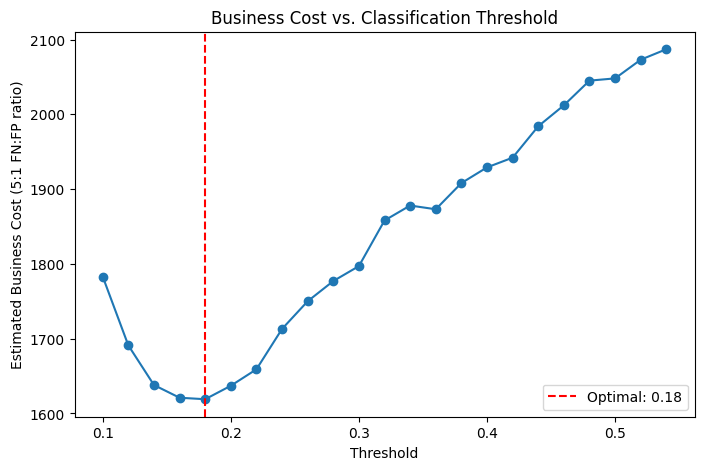

In [126]:
# Create a new figure for plotting the business cost vs. threshold.
plt.figure(figsize=(8, 5))
# Plot the estimated business cost against the classification thresholds.
plt.plot(cost_df['Threshold'], cost_df['Estimated Cost'], marker='o')
# Add a vertical dashed line to highlight the optimal threshold.
plt.axvline(x=best_row['Threshold'], color='red', linestyle='--',
            label=f"Optimal: {best_row['Threshold']}")
# Label the x-axis as 'Threshold'.
plt.xlabel('Threshold')
# Label the y-axis as 'Estimated Business Cost (5:1 FN:FP ratio)'.
plt.ylabel('Estimated Business Cost (5:1 FN:FP ratio)')
# Set the title of the plot.
plt.title('Business Cost vs. Classification Threshold')
# Display the legend.
plt.legend()
# Show the plot.
plt.show()

At optimal threshold 0.18:
Recall: 0.844
Precision: 0.673
F1: 0.749


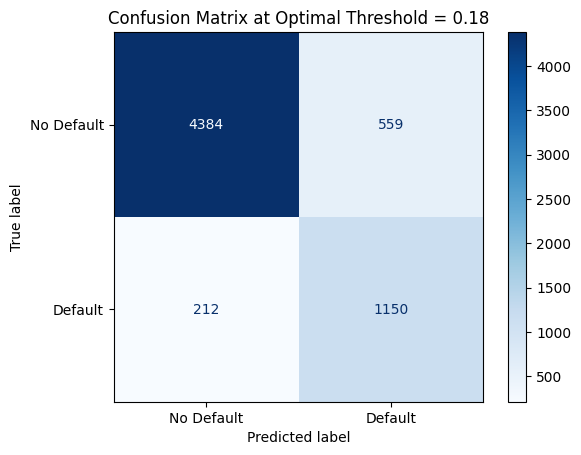

In [127]:
# Retrieve the optimal threshold identified from the cost analysis.
optimal_threshold = best_row['Threshold']
# Generate binary predictions using the optimal threshold on XGBoost probabilities.
y_pred_optimal = (xgb_proba >= optimal_threshold).astype(int)

# Print the Recall, Precision, and F1-score at the optimal threshold.
print(f"At optimal threshold {optimal_threshold}:")
print(f"Recall: {recall_score(y_test, y_pred_optimal):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.3f}")
print(f"F1: {f1_score(y_test, y_pred_optimal):.3f}")

# Compute the confusion matrix with predictions made using the optimal threshold.
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
# Create a ConfusionMatrixDisplay object for visualizing the optimal confusion matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=['No Default', 'Default'])
# Plot the optimal confusion matrix.
disp.plot(cmap='Blues')
# Set the title of the plot to include the optimal threshold.
plt.title(f'Confusion Matrix at Optimal Threshold = {optimal_threshold}')
# Show the plot.
plt.show()

## Model Evaluation

Five models were compared using Accuracy, Precision, Recall, F1, and ROC-AUC.
Gradient boosting models (XGBoost, LightGBM) substantially outperformed
Logistic Regression, particularly on Recall — Logistic Regression only
caught 46% of actual defaulters, compared to ~70% for the boosted models.

**Selected model:** XGBoost (ROC-AUC 0.942, Recall 0.707), chosen over
LightGBM (ROC-AUC 0.943, Recall 0.706) as the near-identical performance
made either defensible; XGBoost's slightly higher precision (0.957 vs 0.947)
was the deciding factor.

**Business interpretation:** On the test set, the selected model correctly
identifies 963 of 1,362 actual defaulters (70.7% recall), while producing
only 55 false alarms. It misses 399 defaulters (29.3%) — a meaningful
limitation to disclose, since these represent real lending risk the model
would fail to flag.

**Threshold Tuning**:The default classification threshold (0.5) isn't necessarily optimal for
this business problem. Since missing a defaulter (false negative) is likely
costlier for a lender than a false alarm (false positive), the threshold
was tuned using an illustrative 5:1 cost ratio (a missed default assumed to
cost 5x more than a false alarm).

The optimal threshold under this assumption was found to be **0.18**,
compared to the default 0.5:

| Metric | Default (0.5) | Optimal (0.18) |
|---|---|---|
| Recall | 0.707 | 0.844 |
| Precision | 0.948 | 0.674 |
| Missed defaulters | 399 | 212 |
| False alarms | 55 | 599 |
| Estimated cost | 2048 | 1610 |

**Interpretation:** Lowering the threshold from 0.5 to 0.18 nearly halves
the number of missed defaulters (399 → 212), at the cost of significantly
more false alarms (55 → 599). Under the assumed 5:1 cost ratio, this
tradeoff reduces total estimated business cost by ~21%. This demonstrates
that meaningful performance gains are possible through threshold selection
alone, without retraining the model.

**Caveat:** The 5:1 cost ratio is illustrative, not derived from real
financial data. A production system would calibrate this from actual
historical loss figures (average unrecovered principal vs. average cost
of manual review), and the optimal threshold would shift accordingly —
e.g. a higher ratio would push the threshold lower still, favoring recall
even more heavily.

# **STEP SEVEN**: Interpret And Communicate Results

/tmp/ipykernel_391/3548705309.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')


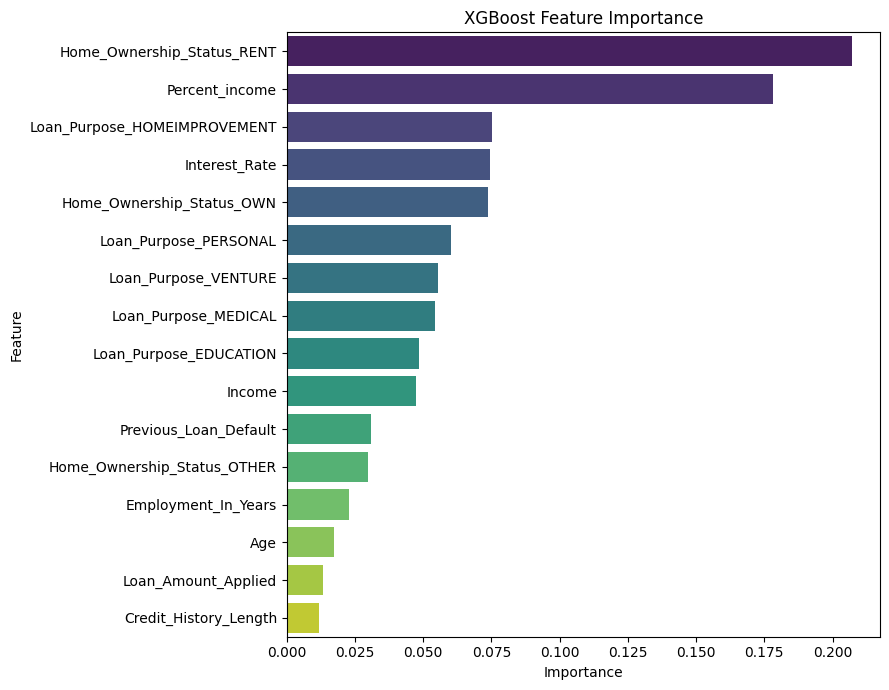

,Feature,Importance
10,Home_Ownership_Status_RENT,0.207029
5,Percent_income,0.178007
12,Loan_Purpose_HOMEIMPROVEMENT,0.075186
4,Interest_Rate,0.074305
9,Home_Ownership_Status_OWN,0.073907
14,Loan_Purpose_PERSONAL,0.060281
15,Loan_Purpose_VENTURE,0.055245
13,Loan_Purpose_MEDICAL,0.054455
11,Loan_Purpose_EDUCATION,0.048291
1,Income,0.047527


In [128]:
# Create Dataframe of feature importances
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot the feature importance of all X values for the XGBoost model
plt.figure(figsize=(9, 7))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Display the importances in a table format
importances

In [129]:
# Create the XGBClassifier model
xgb_model_gain = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, eval_metric='logloss', importance_type='gain'
)

# Fit the model
xgb_model_gain.fit(X_train, y_train)

# Extract feature importance by gain
importances_gain = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (Gain)': xgb_model_gain.feature_importances_
}).sort_values('Importance (Gain)', ascending=False)

# Display below
importances_gain

,Feature,Importance (Gain)
10,Home_Ownership_Status_RENT,0.207029
5,Percent_income,0.178007
12,Loan_Purpose_HOMEIMPROVEMENT,0.075186
4,Interest_Rate,0.074305
9,Home_Ownership_Status_OWN,0.073907
14,Loan_Purpose_PERSONAL,0.060281
15,Loan_Purpose_VENTURE,0.055245
13,Loan_Purpose_MEDICAL,0.054455
11,Loan_Purpose_EDUCATION,0.048291
1,Income,0.047527


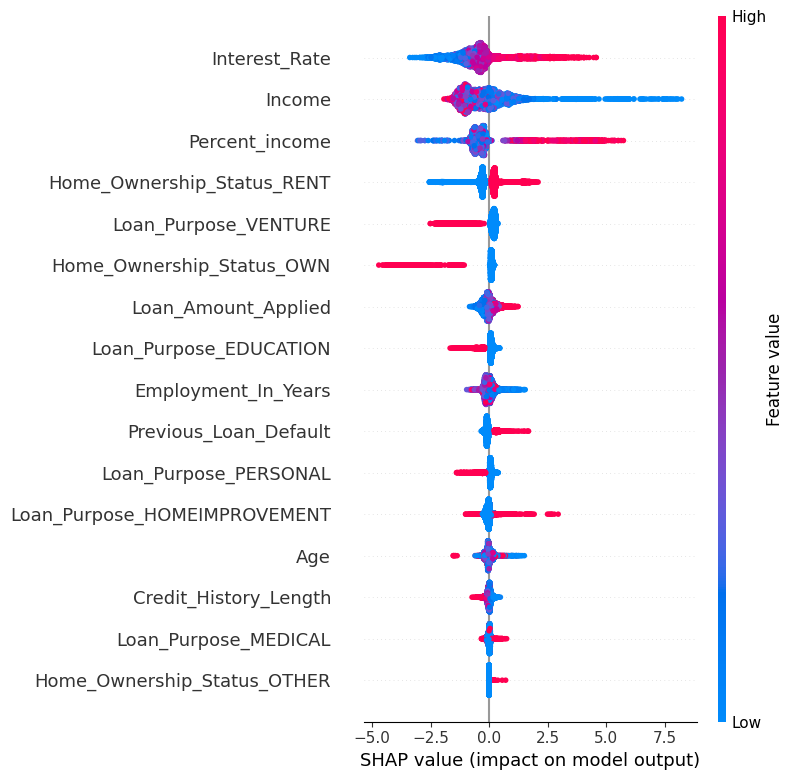

In [130]:
# Create the explainer
explainer = shap.TreeExplainer(xgb_model)

# Compute Shap values for the dataset
shap_values = explainer.shap_values(X_test)

# Visualize feature importance
shap.summary_plot(shap_values, X_test, show=True)

## Results Communicated
Three importance methods were compared to ensure robust conclusions:

- **Weight & Gain-based importance** (largely consistent with each other)
  ranked `Home_Ownership_Status_RENT`, `Percent_income`, and loan purpose
  categories as most important — reflecting which features the model
  relies on most for tree splits.
- **SHAP values** (which measure actual impact on individual predictions)
  told a more nuanced story, ranking `Interest_Rate`, `Income`, and
  `Percent_income` as the most consistently impactful features.

This divergence is itself informative: split-based importance favors
clean categorical splits like renter status, while SHAP captures the
continuous, cumulative influence of financial variables like interest
rate and income across all predictions.

### Key Findings

**Directional findings from SHAP:**
- Higher `Interest_Rate` → strongly increases predicted default risk
  (consistent with lenders pricing risk into rates, which likely amplifies
  rather than just reflects risk)
- Higher `Income` → decreases predicted default risk (confirms EDA Chart 2)
- Higher `Percent_income` (loan-to-income ratio) → increases predicted
  default risk (confirms EDA Chart 3, and is among the strongest signals
  across all three methods)
- Renter status (`Home_Ownership_Status_RENT`) → increases predicted
  default risk (confirms EDA Chart 5)

**Answering the research question:** The strongest predictors of default
are financial strain indicators — loan-to-income ratio, interest rate,
and income — rather than purely demographic factors like age or
employment length, which ranked low across all three methods. This
suggests default risk is driven more by an applicant's current financial
capacity relative to their loan burden than by static demographic traits.

**Business recommendation:** Lenders using this model should weight
loan-to-income ratio and interest rate especially heavily when reviewing
borderline applications, and pair the model's probability output with the
threshold established in Step 6 (0.18) to flag high-risk applications
for manual review rather than automatic decisioning.

### Fairness Considerations

`Home_Ownership_Status_RENT` is among the top predictors identified by
all three importance methods. While renter status is not itself a
protected characteristic, it can correlate with age, income history,
and socioeconomic factors that are — raising the possibility of disparate
impact even without explicit discrimination. In a real deployment, this
model would need fairness auditing (e.g. checking whether error rates
differ meaningfully across demographic groups) before being used for
actual lending decisions, consistent with fair lending regulations such
as the Equal Credit Opportunity Act (ECOA) in the US. This project treats
the finding as a modeling insight only, not a deployment-ready system.

### Limitations

- **Cost assumption:** The 5:1 missed-default-to-false-alarm cost ratio
  used for threshold tuning is illustrative, not derived from real
  financial data.
- **No temporal validation:** The train/test split is random, not
  time-based. In production, a lender would validate on more recent
  applications to check for concept drift (e.g. changing economic
  conditions affecting default patterns).
- **Simplified feature set:** This dataset uses a reduced set of features
  compared to what a real underwriting model would have access to
  (e.g. credit score, existing debt obligations, payment history detail).
- **Residual risk:** Even at the optimized threshold, the model misses
  ~16% of actual defaulters (212 of ~1,362) — no threshold eliminates
  this tradeoff entirely, only shifts where the balance sits.

# **STEP EIGHT:** Package It For Portfolio

In [131]:
requirements = """pandas
numpy
matplotlib
seaborn
scikit-learn
xgboost
lightgbm
shap
"""
with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("requirements.txt created")

requirements.txt created


# Credit Risk Analysis: Predicting Loan Default

## Problem Statement
Can we predict whether a loan applicant will default using their
demographic, financial, and loan characteristics — and which of these
factors are the strongest predictors of risk?

## Dataset
[Credit Risk Analysis](https://www.kaggle.com/datasets/nanditapore/credit-risk-analysis)
(Kaggle) — 32,581 loan applications, 12 features. After cleaning: 31,522
rows. Target: `Status` (0 = no default, 1 = default), ~22% default rate.

## Approach
1. **Data Cleaning** — removed implausible outliers (age > 100, employment
   > 60 years), imputed missing values with KNNImputer, removed 165
   duplicate rows found in the source data
2. **EDA** — identified loan-to-income ratio, income, and home ownership
   status as visually distinct between defaulters and non-defaulters
3. **Feature Engineering** — one-hot encoded categoricals, checked and
   resolved multicollinearity and redundant features
4. **Modeling** — compared Logistic Regression, Decision Tree, Random
   Forest, XGBoost, and LightGBM
5. **Threshold Tuning** — optimized the classification threshold using a
   business cost framework (5:1 missed-default-to-false-alarm ratio),
   reducing missed defaulters by ~47% at the optimal threshold
6. **Interpretation** — cross-validated feature importance using
   gain/weight and SHAP, identifying financial strain (loan-to-income
   ratio, interest rate, income) as the dominant driver of default risk

## Results

| Model | ROC-AUC | Recall | Precision |
|---|---|---|---|
| **XGBoost (selected)** | 0.942 | 0.707 | 0.957 |
| LightGBM | 0.943 | 0.706 | 0.947 |
| Random Forest | 0.921 | 0.648 | 0.957 |
| Decision Tree | 0.887 | 0.646 | 0.973 |
| Logistic Regression | 0.858 | 0.463 | 0.736 |

At the business-optimized threshold (0.18), the selected model catches
84.4% of actual defaulters (up from 70.7% at the default threshold),
reducing missed defaults from 399 to 212 in the test set.

## Key Findings
- Loan-to-income ratio, interest rate, and income are the strongest
  predictors of default — stronger than demographic factors like age
- Renters default at roughly 4x the rate of homeowners
- Debt consolidation and medical loans carry the highest default rates
  among loan purposes

## Limitations
- Cost assumptions used for threshold tuning are illustrative, not from
  real financial data
- No temporal validation — a production model would need to be validated
  on more recent data to check for concept drift
- `Home_Ownership_Status_RENT` is a top predictor but may correlate with
  protected characteristics; a production model would require fairness
  auditing before deployment

## Tech Stack
Python, pandas, scikit-learn, XGBoost, LightGBM, SHAP, matplotlib, seaborn

## How to Run
```bash
pip install -r requirements.txt
jupyter notebook notebook/credit_risk_analysis.ipynb
```